In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
df.shape

(5000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [ ]:
df.describe()
df.describe(include="object")


,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746


In [ ]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [ ]:
df.dtypes

order_id                     int64
order_date          datetime64[ns]
customer_id                  int64
product_category            object
region                      object
quantity                     int64
unit_price                 float64
discount                   float64
payment_method              object
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

In [ ]:
df.describe()

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219


In [ ]:
df.nunique()

order_id            5000
order_date          5000
customer_id          989
product_category       4
region                 4
quantity               7
unit_price          4788
discount              36
payment_method         3
delivery_days         11
customer_rating       41
revenue             4940
dtype: int64

In [ ]:
df["product_category"] = df["product_category"].str.strip().str.title()

df["region"] = df["region"].str.strip().str.title()

df["payment_method"] = df["payment_method"].str.strip().str.title()

In [ ]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

In [ ]:
for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"{col}: {len(outliers)} outliers")

quantity: 0 outliers
unit_price: 0 outliers
discount: 0 outliers
delivery_days: 0 outliers
customer_rating: 0 outliers
revenue: 67 outliers


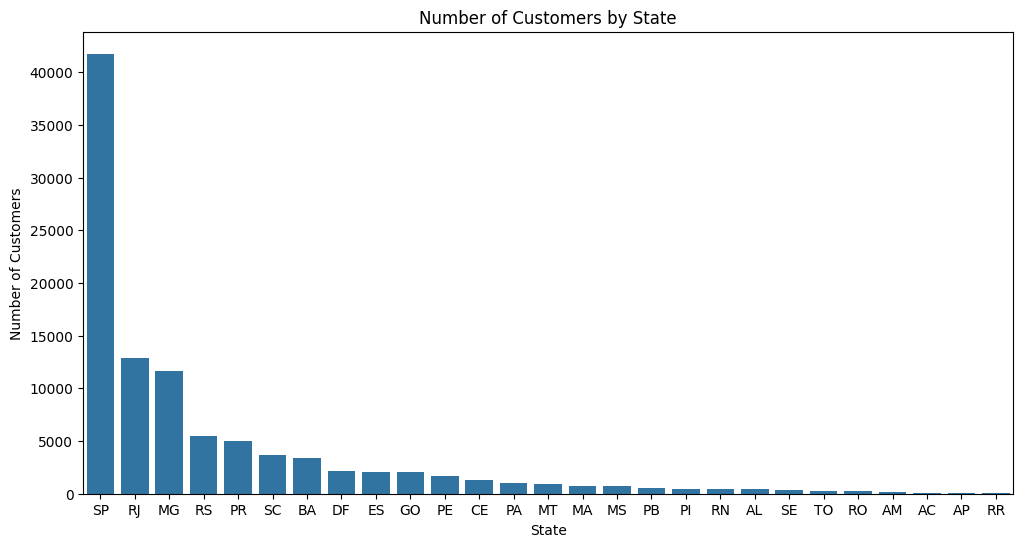

In [ ]:
state_counts = df["customer_state"].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

plt.title("Number of Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#Extract Year
df["order_year"] = df["order_date"].dt.year
#Extract Month
df["order_month"] = df["order_date"].dt.month
#Extract Month Name
df["order_month_name"] = df["order_date"].dt.month_name()
#Extract Day
df["order_day"] = df["order_date"].dt.day

In [ ]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_month_name,order_day
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,January,1
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,January,2
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,Cod,6,2.5,644.35,2022,1,January,3
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,January,4
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,January,5


In [ ]:
df.to_csv(
    "../Data/processed/cleaned_ecommerce_sales.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


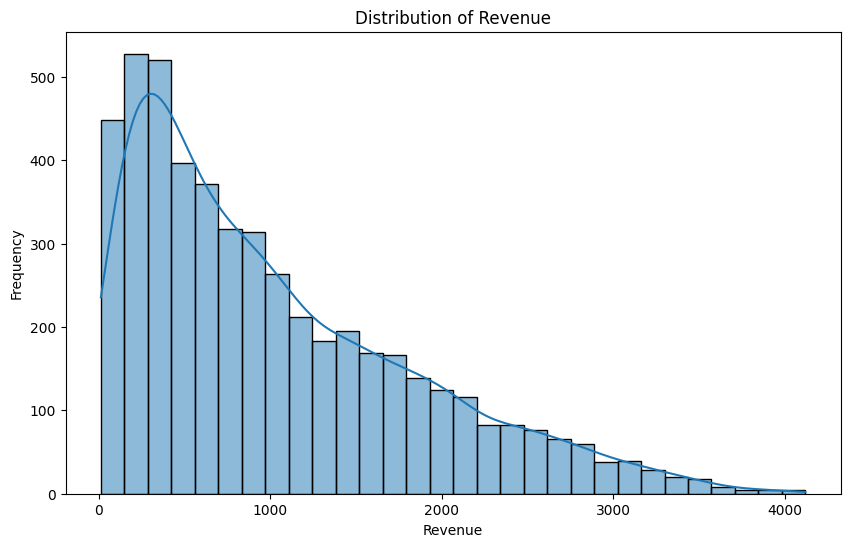

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["revenue"],
    bins=30,
    kde=True
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

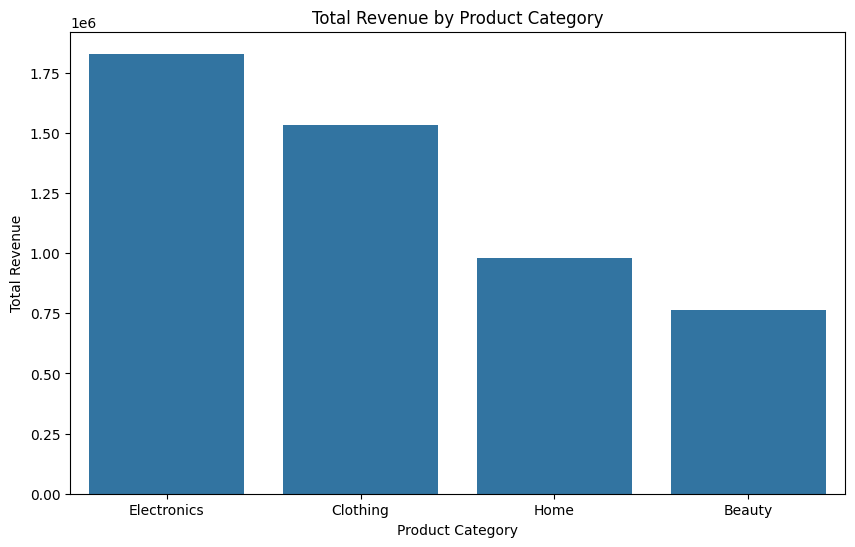

In [ ]:
category_revenue = df.groupby(
    "product_category"
)["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

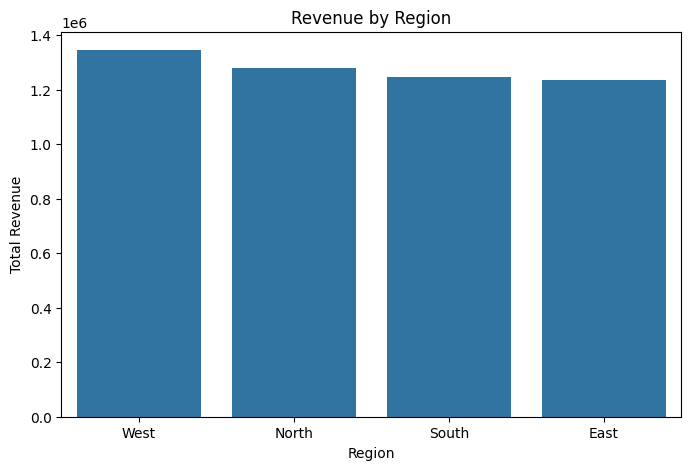

In [ ]:
region_revenue = df.groupby(
    "region"
)["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.show()

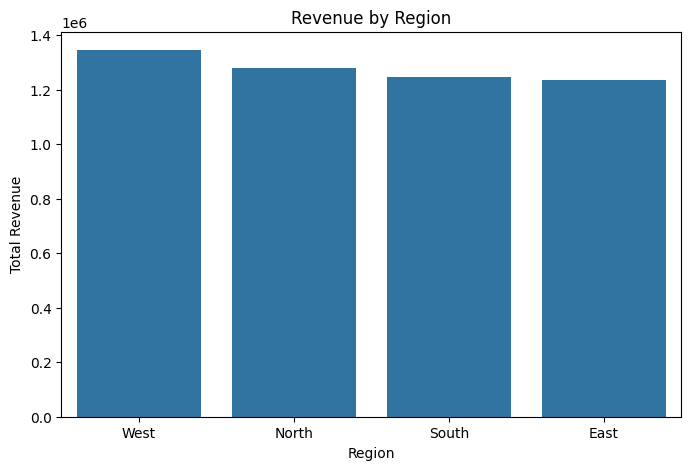

In [ ]:
region_revenue = df.groupby(
    "region"
)["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.show()

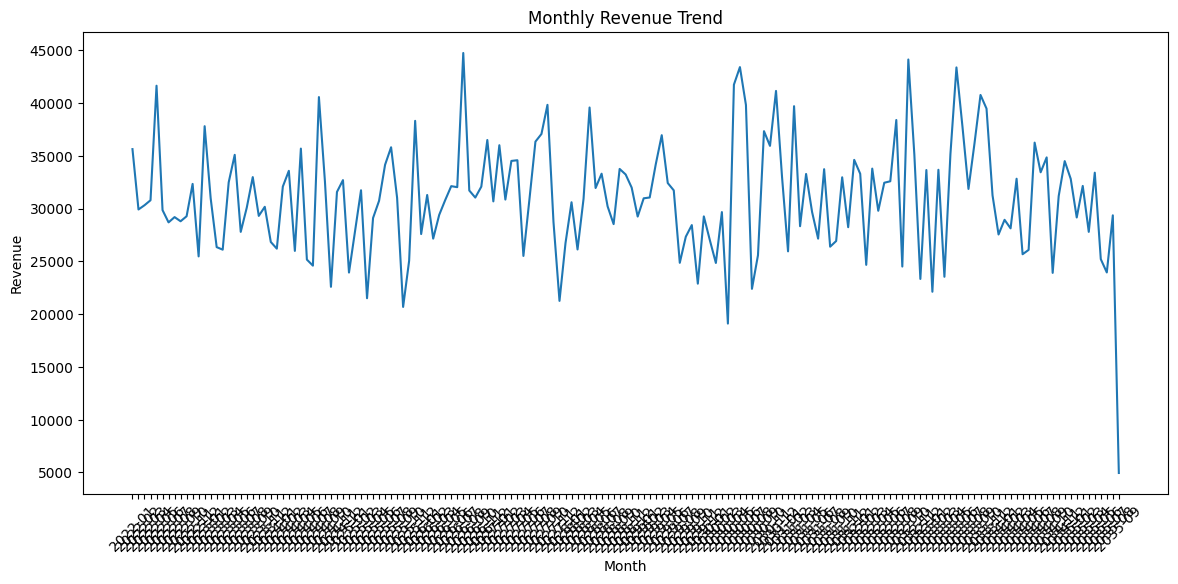

In [ ]:
monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

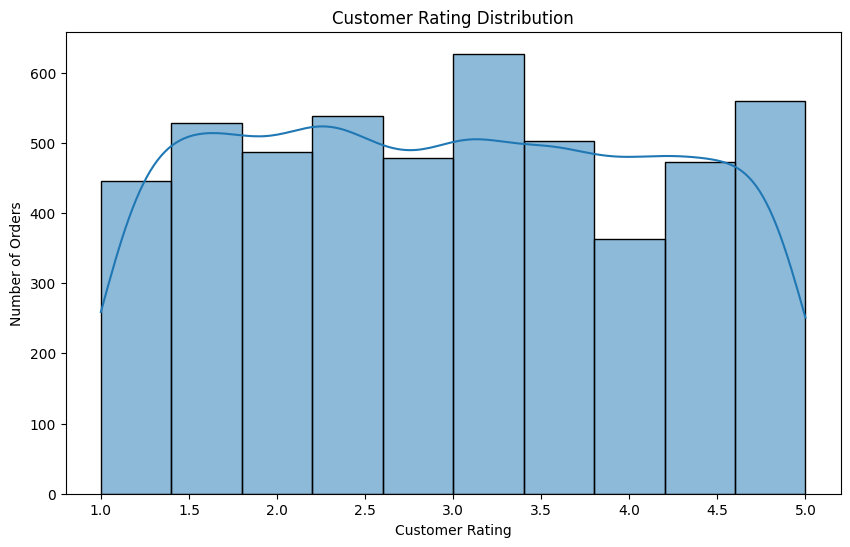

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["customer_rating"],
    bins=10,
    kde=True
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")

plt.show()

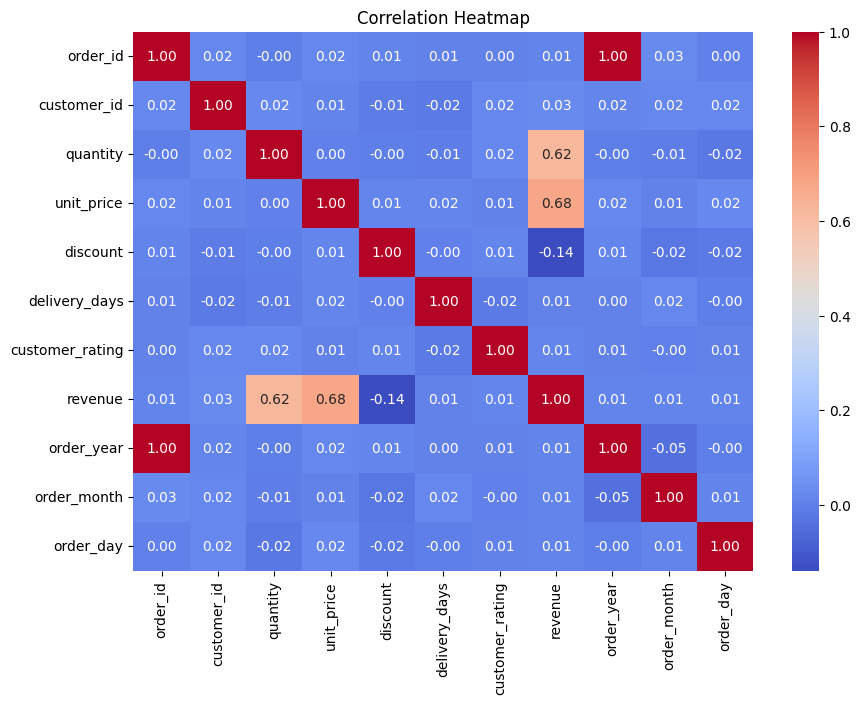

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights and Conclusion

Based on the data cleaning and exploratory data analysis, the following key insights were identified:

1. The dataset contains 5,000 E-Commerce sales records and 12 original attributes.

2. No missing values or duplicate records were found, indicating that the dataset is well structured.

3. The `order_date` column was converted into datetime format to support time-based analysis.

4. Additional features such as order year, month, month name, and day were created to improve the analysis.

5. Revenue analysis helps identify high-performing product categories and regions.

6. Payment method analysis provides insights into customer purchasing preferences.

7. Monthly revenue trends can help identify changes in sales performance over time.

8. Customer rating analysis provides insights into customer satisfaction.

9. Correlation analysis helps identify relationships between important numerical variables.

## Conclusion

The data cleaning and exploratory data analysis process provides a strong foundation for understanding E-Commerce sales performance. The insights generated from this analysis can support business decision-making, including product strategy, regional sales planning, customer experience improvement, and future revenue analysis.